In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/himanshunakrani/iris-dataset/iris.csv
/kaggle/input/datasets/hemanthmallarapu/fueldata/CO2 Emissions_Canada.csv


**REGRESSION**

In [2]:
df=pd.read_csv("/kaggle/input/datasets/hemanthmallarapu/fueldata/CO2 Emissions_Canada.csv")
df.head()


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

In [4]:
df.isna().sum()

Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64

In [5]:
df=df.rename(columns={"Engine Size(L)":"EngSize","CO2 Emissions(g/km)":"CO2Em"})
df

,Make,Model,Vehicle Class,EngSize,Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2Em
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...
7380,VOLVO,XC40 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,10.7,7.7,9.4,30,219
7381,VOLVO,XC60 T5 AWD,SUV - SMALL,2.0,4,AS8,Z,11.2,8.3,9.9,29,232
7382,VOLVO,XC60 T6 AWD,SUV - SMALL,2.0,4,AS8,Z,11.7,8.6,10.3,27,240
7383,VOLVO,XC90 T5 AWD,SUV - STANDARD,2.0,4,AS8,Z,11.2,8.3,9.9,29,232


**LINEAR REGRESSION**

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[["EngSize"]]
Y = df["CO2Em"] 

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

lr = LinearRegression()
lr.fit(X_train, Y_train)

y_pred = lr.predict(X_test)
print(y_pred)

[244.89311066 296.15016006 362.05208072 ... 186.31362563 263.19919973
 208.28093252]


In [7]:
acc=r2_score(Y_test,y_pred)
print(acc*100)

72.38115822302345


**RIDGE REGRESSION**

In [8]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

features=df[['EngSize','Cylinders',
            'Fuel Consumption City (L/100 km)',
            'Fuel Consumption Hwy (L/100 km)',
            'Fuel Consumption Comb (L/100 km)',
            'Fuel Consumption Comb (mpg)'
            ]]
X=features
Y=df['CO2Em']

model=Ridge(alpha=10)
model.fit(X,Y)

Ridge(alpha=10)

In [9]:
for col, coef in zip(X.columns,model.coef_):
    print(col,coef)

EngSize 4.988896861534219
Cylinders 7.530001905563055
Fuel Consumption City (L/100 km) -0.07441141587902007
Fuel Consumption Hwy (L/100 km) 4.420374226096922
Fuel Consumption Comb (L/100 km) 1.7942267392055955
Fuel Consumption Comb (mpg) -3.4227207952890164


**LASSO REGRESSION**

In [10]:
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

X=df[['EngSize',
 'Cylinders',
 'Fuel Consumption City (L/100 km)',
 'Fuel Consumption Hwy (L/100 km)',
 'Fuel Consumption Comb (L/100 km)',
 'Fuel Consumption Comb (mpg)'
]]

Y=df['CO2Em']

ls=Lasso(alpha=10)
ls.fit(X,Y)

Lasso(alpha=10)

In [11]:
for col,coef in zip(X.columns,ls.coef_):
  print(col,coef)

EngSize 0.0
Cylinders 4.904591730355428
Fuel Consumption City (L/100 km) 3.6794134206752385
Fuel Consumption Hwy (L/100 km) 0.0
Fuel Consumption Comb (L/100 km) 0.0
Fuel Consumption Comb (mpg) -4.607823475560298


**EVALUATION METRICS**

In [12]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(Y_test,y_pred)
mse

949.9852533375358

**MEAN ABSOLUTE**

In [13]:
from sklearn.metrics import mean_absolute_error
mse=mean_absolute_error(Y_test,y_pred)
mse

22.927177134342056

**REAL MEAN**

In [14]:
rmse=np.sqrt(mse)
print(rmse)

4.788233195484746


**GRADIENT DESCENT**

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   EngSize                           7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2Em                             7385 non-null   int64  
dtypes: flo

In [16]:
X_val=df["EngSize"].values
Y_val=df["CO2Em"].values
m=0
c=0
lr=0.01
epoch=1000 

In [17]:
n=len(X_val)
costhistory=[]
for epoch_count in range(epoch):
  y_predict=m*X_val+c
  cost=1/n*np.sum((Y_val-y_predict)**2)
  gdm=(-2/n)*np.sum(X_val*(Y_val-y_predict)) 
  gdc=(-2/n)*np.sum(Y_val-y_predict)         
  m=m-(lr*gdm)
  c=c-(lr*gdc)
  costhistory.append(cost)

print("Slope",m)
print("Intercept",c)
print("GDM",gdm)
print("GDC",gdc)
print(costhistory[-1])

Slope 38.50828574295661
Intercept 127.97080623961894
GDM 0.5022516085522223
GDC -1.8555731414538401
949.6780734785445


**STANDARDIZATION**

In [18]:
from sklearn.preprocessing import StandardScaler

X = df[["EngSize",
        "Cylinders",
        "Fuel Consumption City (L/100 km)",
        "Fuel Consumption Hwy (L/100 km)",
        "Fuel Consumption Comb (L/100 km)",
        "Fuel Consumption Comb (mpg)"]]

sc = StandardScaler()
X_standardized = sc.fit_transform(X)

print(X_standardized)

[[-0.85672099 -0.88340757 -0.75900153 -1.05278069 -0.85574185  0.76311032]
 [-0.5613172  -0.88340757 -0.3875769  -0.60320221 -0.47542306  0.20996629]
 [-1.22597573 -0.88340757 -1.87327544 -1.45740132 -1.75467716  2.83740047]
 ...
 [-0.85672099 -0.88340757 -0.24472127 -0.19858158 -0.23340202 -0.06660573]
 [-0.85672099 -0.88340757 -0.3875769  -0.33345513 -0.37169976  0.20996629]
 [-0.85672099 -0.88340757 -0.10186564 -0.15362374 -0.09510428 -0.20489174]]


In [19]:
data=pd.read_csv("/kaggle/input/datasets/himanshunakrani/iris-dataset/iris.csv")
data.head
data.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

**CLASSIFICATION**

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [21]:
data.columns.tolist()

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

In [22]:
X=data[["sepal_length","sepal_width","petal_length","petal_width"]]
X 

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [23]:
Y=data['species']
Y 

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

In [24]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=45)

In [25]:
mymodel=DecisionTreeClassifier() #object creation to access the methods of the class
mymodel.fit(x_train,y_train) #train our model to learn from the given dataset

DecisionTreeClassifier()

In [26]:
prediction=mymodel.predict(x_test) # this is used to predict the outcome based on the test data
print(y_test)
print(prediction.tolist())

0          setosa
43         setosa
129     virginica
3          setosa
34         setosa
44         setosa
38         setosa
105     virginica
123     virginica
140     virginica
28         setosa
125     virginica
113     virginica
103     virginica
133     virginica
35         setosa
145     virginica
142     virginica
40         setosa
87     versicolor
84     versicolor
85     versicolor
115     virginica
51     versicolor
4          setosa
112     virginica
92     versicolor
64     versicolor
10         setosa
91     versicolor
Name: species, dtype: object
['setosa', 'setosa', 'virginica', 'setosa', 'setosa', 'setosa', 'setosa', 'virginica', 'virginica', 'virginica', 'setosa', 'virginica', 'virginica', 'virginica', 'versicolor', 'setosa', 'virginica', 'virginica', 'setosa', 'versicolor', 'versicolor', 'versicolor', 'virginica', 'versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor', 'setosa', 'versicolor']


**GRAPHS**

SCATTER PLOT

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

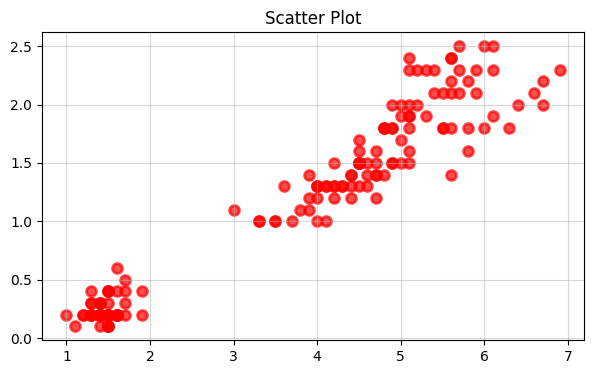

In [28]:
plt.figure(figsize=(7,4),facecolor="white")
plt.scatter(data["petal_length"],data["petal_width"],s=50,c="red",marker="o",lw=2,alpha=0.7)
plt.title("Scatter Plot")
plt.grid(True,alpha=0.5)
plt.show()

In [29]:
HISTOGRAM

NameError: name 'HISTOGRAM' is not defined

In [ ]:
plt.figure(figsize=(8,5),facecolor="white")
plt.hist(data["petal_length"],bins=10,color="blue",edgecolor="black",lw=2,alpha=0.7)
plt.title("Histogram")
plt.grid(axis='y',alpha=0.3)
plt.show()

In [ ]:
KDE PLOT

In [ ]:
import seaborn as sns


In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14,6))
sns.kdeplot(data["sepal_width"],fill=True)
plt.title("Kernel Density Plot")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(7,4),facecolor="yellow") 
plt.bar(data["species"],data["sepal_length"])
plt.title("Bar plot")
plt.show()

In [ ]:
srs=data.sample(n=20,random_state=42)
print(srs)

In [ ]:
srs.shape

In [ ]:
setosa = data[data["species"]=="setosa"]
versicolor = data[data["species"]=="versicolor"]
virginica = data[data["species"]=="virginica"]

sample_setosa = setosa.sample(n=10,random_state=42)
sample_versicolor = versicolor.sample(n=10,random_state=42)
sample_virginica = virginica.sample(n=10,random_state=42)

stratified_sample = pd.concat([sample_setosa,sample_versicolor,sample_virginica],ignore_index=True)

print(stratified_sample)